In [6]:
import sklearn.utils

def check_matplotlib_support(caller_name):
    try:
        import matplotlib
    except ImportError:
        raise ImportError(
            "Matplotlib is required for plotting functions in " + caller_name
        )

setattr(sklearn.utils, 'check_matplotlib_support', check_matplotlib_support)

In [23]:
import gc
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklift.datasets import fetch_x5
from sklift.models import TwoModels
from sklift.metrics import uplift_auc_score, qini_auc_score
import optuna
from feature_extraction import UpliftFeatureExtractor
import matplotlib.pyplot as plt

from sklift.metrics import uplift_at_k
from sklift.viz import plot_uplift_curve, plot_qini_curve

import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [8]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names"
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [9]:
dataset = fetch_x5()
data = dataset.data

In [10]:
# подсчет фич
extractor = UpliftFeatureExtractor(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

del data
gc.collect()

features = extractor.feature_names

print(f"Создано признаков: {len(features)}")
print(f"Размер датафрейма: {df.shape}")
print(f"Признаки: {features}")

Создано признаков: 32
Размер датафрейма: (200039, 34)
Признаки: ['first_issue_month', 'first_issue_weekday', 'first_issue_year_quarter_idx', 'total_transactions', 'avg_transaction_amount', 'max_transaction_amount', 'min_transaction_amount', 'total_express_points_received', 'total_express_points_spent', 'avg_express_points_per_transaction', 'points_earned_to_spent_ratio', 'unique_products_count', 'avg_product_quantity', 'transaction_period_days', 'first_transaction_quarter', 'first_transaction_year_quarter_idx', 'unique_stores_visited', 'store_loyalty_ratio', 'avg_purchase_per_day', 'transactions_per_month', 'points_spend_ratio', 'points_balance_ratio', 'unique_store_intensity', 'log_total_purchase_sum', 'seasonal_quarter_code', 'avg_items_per_transaction', 'spend_points_per_transaction', 'transaction_value_density', 'is_super_loyal', 'age', 'gender', 'is_activated']


In [11]:
target = 'target' 
treatment = 'treatment_flg'

In [12]:
X_raw = df[features]
y = df[target].astype(int).values
t = df[treatment].astype(int).values

NUM_COLS = X_raw.select_dtypes(include='number').columns.tolist()
CAT_COLS = X_raw.select_dtypes(include='object').columns.tolist()

print("Числовые фичи:", NUM_COLS)
print("Категориальные фичи:", CAT_COLS)

import numpy as np

strata = np.array(list(zip(df[treatment], df[target])))
# strata – массив пар (0,0), (1,0), ...

# кодируем пары в категории
_, strata_encoded = np.unique(strata, axis=0, return_inverse=True)

X_train_raw, X_test_raw, y_train, y_test, t_train, t_test = train_test_split(
    X_raw, y, t,
    test_size=0.3,
    random_state=42,
    stratify=strata_encoded # чтобы доли классов были одинаковые в выборке
)

Числовые фичи: ['first_issue_month', 'first_issue_weekday', 'first_issue_year_quarter_idx', 'total_transactions', 'avg_transaction_amount', 'max_transaction_amount', 'min_transaction_amount', 'total_express_points_received', 'total_express_points_spent', 'avg_express_points_per_transaction', 'points_earned_to_spent_ratio', 'unique_products_count', 'avg_product_quantity', 'transaction_period_days', 'first_transaction_year_quarter_idx', 'unique_stores_visited', 'store_loyalty_ratio', 'avg_purchase_per_day', 'transactions_per_month', 'points_spend_ratio', 'points_balance_ratio', 'unique_store_intensity', 'log_total_purchase_sum', 'seasonal_quarter_code', 'avg_items_per_transaction', 'spend_points_per_transaction', 'transaction_value_density', 'is_super_loyal', 'age', 'is_activated']
Категориальные фичи: ['first_transaction_quarter']


In [24]:
def build_preprocessor():
    transformers = []
    if len(NUM_COLS) > 0:
        transformers.append(("num", StandardScaler(), NUM_COLS))
    if len(CAT_COLS) > 0:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS))
    
    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")
    return preprocessor


# Предобрабатываем данные один раз до начала оптимизации
print("Предобработка данных...")
preprocessor = build_preprocessor()
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

print(f"Размер после предобработки: {X_train_processed.shape}")

# Преобразуем в dense если нужно
if hasattr(X_train_processed, 'toarray'):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print(f"Размер dense массива: {X_train_processed.shape}")


class UpliftNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.3):
        super(UpliftNN, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


class SklearnNNWrapper(BaseEstimator, ClassifierMixin):
    """PyTorch нейросеть с совместимостью scikit-learn"""
    
    def __init__(self, input_dim=None, hidden_dims=[128, 64, 32], dropout=0.3, 
                 lr=0.001, batch_size=256, epochs=50, device='cpu'):
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.device = device
        self.model_ = None
        self.classes_ = np.array([0, 1])
    
    def fit(self, X, y):
        # Проверка входных данных
        X, y = check_X_y(X, y, accept_sparse=False)
        
        # Определяем входную размерность
        if self.input_dim is None:
            self.input_dim_ = X.shape[1]
        else:
            self.input_dim_ = self.input_dim
        
        # Конвертация в тензоры
        X_tensor = torch.FloatTensor(X).to(self.device)
        y_tensor = torch.FloatTensor(y).reshape(-1, 1).to(self.device)
        
        # Создание модели
        self.model_ = UpliftNN(
            input_dim=self.input_dim_,
            hidden_dims=self.hidden_dims,
            dropout=self.dropout
        ).to(self.device)
        
        # Обучение
        criterion = nn.BCELoss()
        optimizer = optim.Adam(self.model_.parameters(), lr=self.lr)
        
        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model_.train()
        for epoch in range(self.epochs):
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                outputs = self.model_(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
        
        return self
    
    def predict_proba(self, X):
        check_is_fitted(self, 'model_')
        X = check_array(X, accept_sparse=False)
        
        X_tensor = torch.FloatTensor(X).to(self.device)
        
        self.model_.eval()
        with torch.no_grad():
            predictions = self.model_(X_tensor).cpu().numpy()
        
        return np.hstack([1 - predictions, predictions])
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)


def build_base_estimator(model_name, params, input_dim):
    """Создает нейросетевой классификатор"""
    nn_wrapper = SklearnNNWrapper(
        input_dim=input_dim,
        hidden_dims=params.get('hidden_dims', [128, 64, 32]),
        dropout=params.get('dropout', 0.3),
        lr=params.get('lr', 0.001),
        batch_size=params.get('batch_size', 256),
        epochs=params.get('epochs', 50),
        device=device
    )
    return nn_wrapper

Предобработка данных...
Размер после предобработки: (140027, 32)
Размер dense массива: (140027, 32)


In [25]:
def make_objective(model_name: str,
                   X: np.ndarray,
                   y: np.ndarray,
                   t: np.ndarray,
                   n_splits: int = 3):
    
    def objective(trial: optuna.Trial) -> float:
        params = {
            'hidden_dims': trial.suggest_categorical('hidden_dims', [[64, 32], [128, 64, 32], [256, 128, 64]]),
            'dropout': trial.suggest_float('dropout', 0.1, 0.5),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [128, 256, 512]),
            'epochs': trial.suggest_int('epochs', 20, 80, step=10),
        }
        
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = []
        input_dim = X.shape[1]
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            t_tr, t_val = t[train_idx], t[val_idx]
            
            base_trmnt = build_base_estimator(model_name, params, input_dim)
            base_ctrl = build_base_estimator(model_name, params, input_dim)
            
            tm = TwoModels(estimator_trmnt=base_trmnt, estimator_ctrl=base_ctrl, method='vanilla')
            
            try:
                tm.fit(X_tr, y_tr, t_tr)
                uplift_val = tm.predict(X_val)
                score = uplift_auc_score(y_true=y_val, uplift=uplift_val, treatment=t_val)
                scores.append(score)
                print(f"Fold {fold+1}/{n_splits} AUUC: {score:.6f}")
            except Exception as e:
                print(f"Error in fold {fold+1}: {e}")
                return float('-inf')
        
        if len(scores) == 0:
            return float('-inf')
        
        mean_score = float(np.mean(scores))
        print(f"[{model_name}] Trial {trial.number}: Mean AUUC={mean_score:.6f}")
        return mean_score
    
    return objective

In [26]:
study = optuna.create_study(direction="maximize", study_name="t_learner_nn_auuc")
study.optimize(
    make_objective(
        model_name='nn', 
        X=X_train_processed, 
        y=y_train, 
        t=t_train,
        n_splits=3
    ),
    n_trials=10
)

print(f"\nЛучший AUUC по CV: {study.best_value:.6f}")
print(f"Лучшие параметры: {study.best_params}")

Fold 1/3 AUUC: 0.017279
Fold 2/3 AUUC: 0.021161
Fold 3/3 AUUC: 0.021245
[nn] Trial 0: Mean AUUC=0.019895
Fold 1/3 AUUC: 0.017531
Fold 2/3 AUUC: 0.021128
Fold 3/3 AUUC: 0.020387
[nn] Trial 1: Mean AUUC=0.019682
Fold 1/3 AUUC: 0.014047
Fold 2/3 AUUC: 0.013926
Fold 3/3 AUUC: 0.016880
[nn] Trial 2: Mean AUUC=0.014951
Fold 1/3 AUUC: 0.016727
Fold 2/3 AUUC: 0.016177
Fold 3/3 AUUC: 0.014210
[nn] Trial 3: Mean AUUC=0.015704
Fold 1/3 AUUC: 0.018223
Fold 2/3 AUUC: 0.019631
Fold 3/3 AUUC: 0.020524
[nn] Trial 4: Mean AUUC=0.019459
Fold 1/3 AUUC: 0.021664
Fold 2/3 AUUC: 0.022329
Fold 3/3 AUUC: 0.023560
[nn] Trial 5: Mean AUUC=0.022518
Fold 1/3 AUUC: 0.019264
Fold 2/3 AUUC: 0.023782
Fold 3/3 AUUC: 0.023277
[nn] Trial 6: Mean AUUC=0.022108
Fold 1/3 AUUC: 0.018693
Fold 2/3 AUUC: 0.028486
Fold 3/3 AUUC: 0.020235
[nn] Trial 7: Mean AUUC=0.022472
Fold 1/3 AUUC: 0.016838
Fold 2/3 AUUC: 0.027481
Fold 3/3 AUUC: 0.019502
[nn] Trial 8: Mean AUUC=0.021274
Fold 1/3 AUUC: 0.020709
Fold 2/3 AUUC: 0.023914
Fold 3/

In [27]:
best_params = study.best_params
input_dim = X_train_processed.shape[1]

print(f"\nОбучение финальной модели с параметрами: {best_params}")

base_trmnt = build_base_estimator('nn', best_params, input_dim)
base_ctrl = build_base_estimator('nn', best_params, input_dim)

tm = TwoModels(estimator_trmnt=base_trmnt, estimator_ctrl=base_ctrl, method='vanilla')
tm.fit(X_train_processed, y_train, t_train)

uplift_test = tm.predict(X_test_processed)

auuc_test = uplift_auc_score(y_true=y_test, uplift=uplift_test, treatment=t_test)
qini_test = qini_auc_score(y_true=y_test, uplift=uplift_test, treatment=t_test)

KS = [0.1, 0.2, 0.3, 0.5]
print(f"\nРезультаты нейросетевого T-learner:")
print(f"AUUC = {auuc_test:.6f}")
print(f"Qini = {qini_test:.6f}")
for k in KS:
    u_k = uplift_at_k(y_true=y_test, uplift=uplift_test, treatment=t_test, strategy="overall", k=k)
    print(f"Uplift@{int(k*100)}% = {u_k:.6f}")


Обучение финальной модели с параметрами: {'hidden_dims': [64, 32], 'dropout': 0.22338843352395796, 'lr': 0.00032488253588586755, 'batch_size': 512, 'epochs': 60}

Результаты нейросетевого T-learner:
AUUC = 0.015978
Qini = 0.010389
Uplift@10% = 0.102764
Uplift@20% = 0.069363
Uplift@30% = 0.054729
Uplift@50% = 0.048711


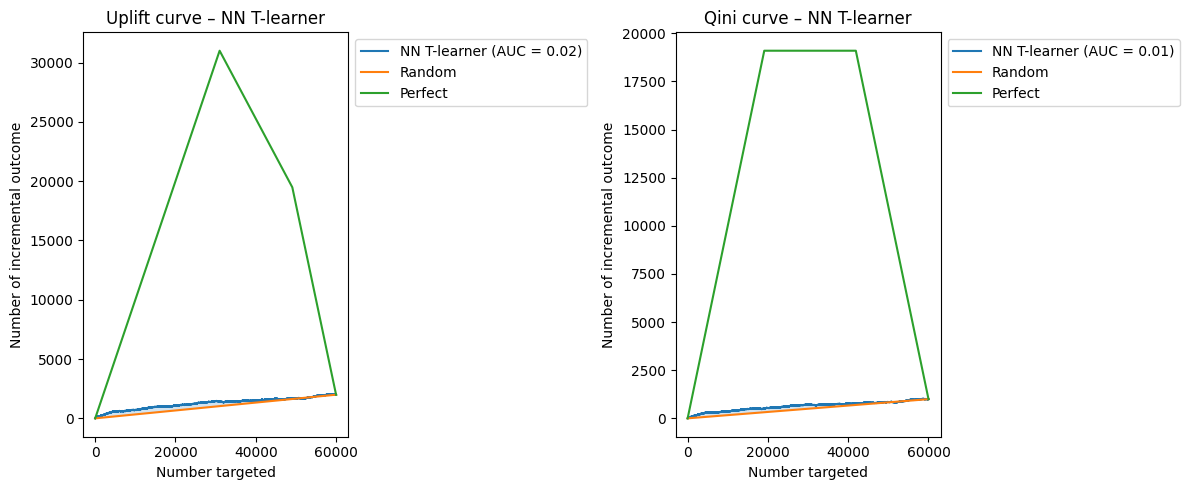

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_uplift_curve(y_true=y_test, uplift=uplift_test, treatment=t_test, perfect=True, random=True, name="NN T-learner", ax=axes[0])
axes[0].set_title("Uplift curve – NN T-learner")

plot_qini_curve(y_true=y_test, uplift=uplift_test, treatment=t_test, perfect=True, random=True, name="NN T-learner", ax=axes[1])
axes[1].set_title("Qini curve – NN T-learner")

plt.tight_layout()
plt.show()